<a href="https://colab.research.google.com/github/Ganzer13/data-science-2026/blob/main/Pertemuan5_Roland_240401010294.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

df['age'] = df['age'].fillna(df['age'].median())

print("Dimensi data:", df.shape)
print("\nTipe Data:\n", df.dtypes)

Dimensi data: (891, 15)

Tipe Data:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


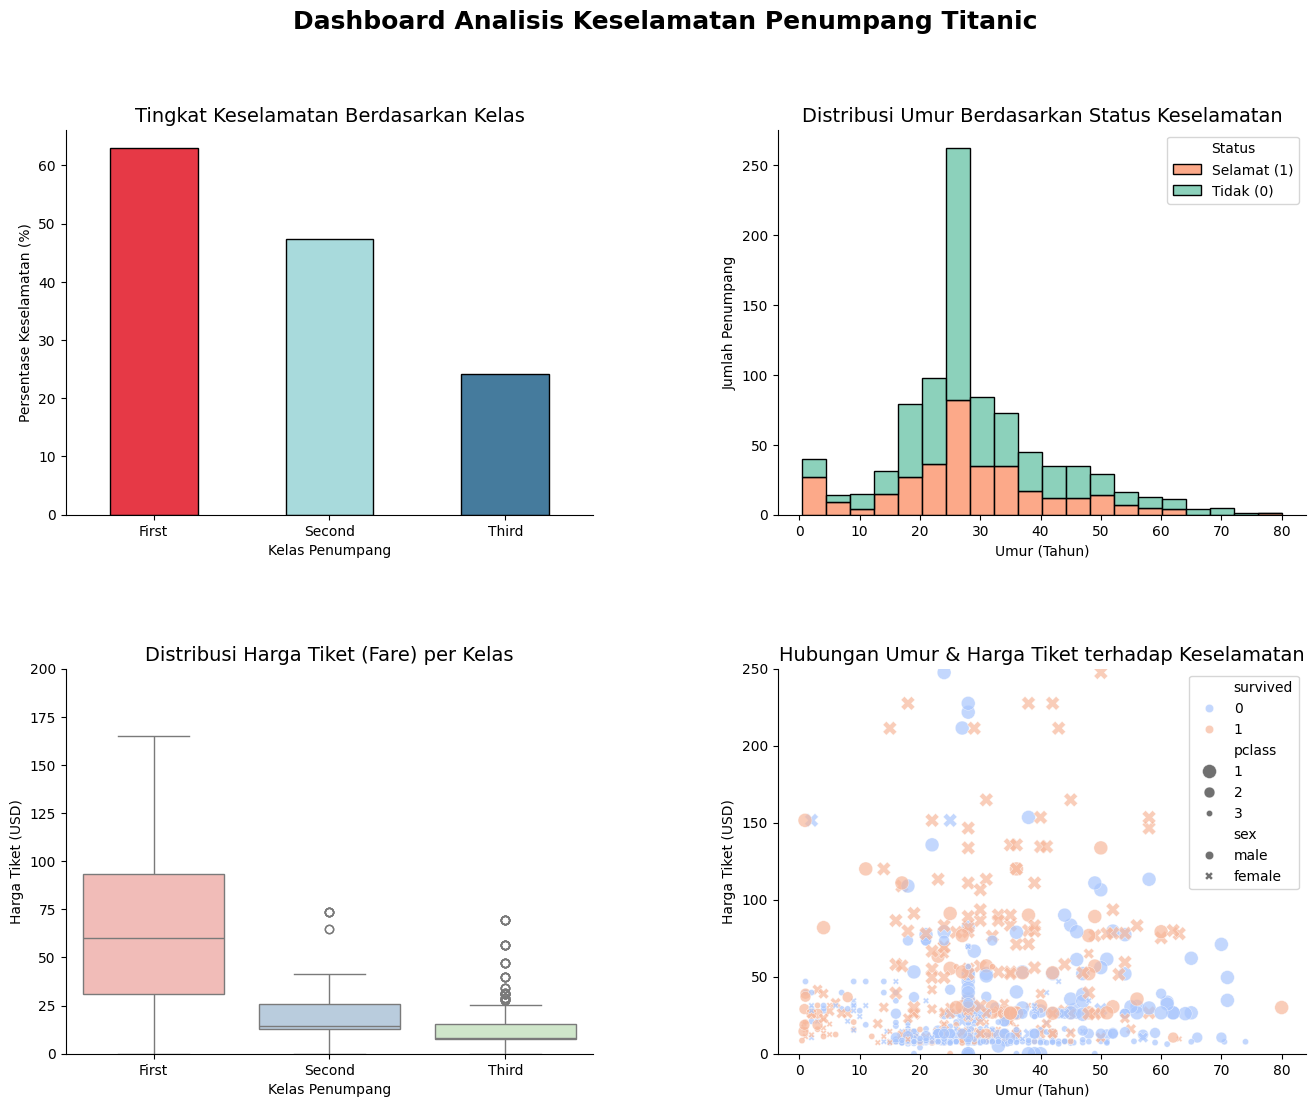

Dashboard tersimpan sebagai dashboard_titanic.png


In [3]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Keselamatan Penumpang Titanic', fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── 3. GRAFIK 1: Bar Chart (Keselamatan per Kelas) ────────────────────
survival_rate = df.groupby('class', observed=True)['survived'].mean() * 100
survival_rate.plot(kind='bar', ax=ax1, color=['#e63946', '#a8dadc', '#457b9d'], edgecolor='black')
ax1.set_title('Tingkat Keselamatan Berdasarkan Kelas', fontsize=14)
ax1.set_xlabel('Kelas Penumpang')
ax1.set_ylabel('Persentase Keselamatan (%)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE (Distribusi Umur) ────────────────────
sns.histplot(data=df, x='age', hue='survived', multiple='stack', bins=20, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Umur Berdasarkan Status Keselamatan', fontsize=14)
ax2.set_xlabel('Umur (Tahun)')
ax2.set_ylabel('Jumlah Penumpang')
ax2.legend(title='Status', labels=['Selamat (1)', 'Tidak (0)'])
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot (Distribusi Harga Tiket per Kelas) ───────────
sns.boxplot(data=df, x='class', y='fare', hue='class', palette='Pastel1', ax=ax3)
ax3.set_title('Distribusi Harga Tiket (Fare) per Kelas', fontsize=14)
ax3.set_xlabel('Kelas Penumpang')
ax3.set_ylabel('Harga Tiket (USD)')
ax3.set_ylim(0, 200) # Membatasi sumbu Y agar grafik lebih jelas dibaca (mengabaikan outlier ekstrem)
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot (Umur vs Harga Tiket) ───────────────────
sns.scatterplot(data=df, x='age', y='fare', hue='survived', style='sex',
                size='pclass', sizes=(100, 20), palette='coolwarm', alpha=0.7, ax=ax4)
ax4.set_title('Hubungan Umur & Harga Tiket terhadap Keselamatan', fontsize=14)
ax4.set_xlabel('Umur (Tahun)')
ax4.set_ylabel('Harga Tiket (USD)')
ax4.set_ylim(0, 250)
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ─────────────────────────────────────────────────────────
plt.savefig('dashboard_titanic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_titanic.png')

**Analisis Bar Chart**

**What:** Grafik batang menunjukkan tingkat keselamatan penumpang Titanic berdasarkan kelas tiketnya, di mana penumpang Kelas 1 memiliki tingkat keselamatan tertinggi sekitar 62.9%, berbanding terbalik dengan Kelas 3 yang hanya mencapai 24.2%.

**So what:** Perbedaan drastis sebesar hampir 38% ini sangat penting karena merepresentasikan adanya prioritas akses evakuasi dan pembagian sekoci penyelamat yang sangat dipengaruhi oleh status sosial ekonomi penumpang saat bencana terjadi.

**Now what:** Sebagai tindak lanjut, kita perlu membedah lebih dalam data Kelas 1 dan Kelas 3 ini berdasarkan gender untuk melihat apakah laki-laki di Kelas 1 memiliki peluang hidup yang lebih baik daripada perempuan di Kelas 3.

**Analisis Histogram**

**What:** Histogram menunjukkan bahwa mayoritas penumpang berada pada rentang usia 20 hingga 30 tahun (tertinggi mencapai >150 orang), dan terdapat lonjakan keselamatan yang mencolok pada kelompok balita/anak-anak (usia 0-10 tahun).

**So what:** Tingginya proporsi area hijau (selamat) pada rentang usia 0-10 tahun membuktikan bahwa protokol darurat maritim "women and children first" (wanita dan anak-anak terlebih dahulu) benar-benar diterapkan secara efektif saat kapal tenggelam.

**Now what:** Pertanyaan eksplorasi selanjutnya adalah apakah anak-anak dari keluarga Kelas 3 mendapatkan prioritas evakuasi yang sama tingginya dengan anak-anak dari keluarga Kelas 1 dan Kelas 2.

**Analisis Boxplot**

**What:** Boxplot memperlihatkan ketimpangan yang ekstrem pada distribusi harga tiket, di mana median (nilai tengah) tiket Kelas 1 berada di sekitar 60 USD, sedangkan median tiket Kelas 3 sangat murah, yakni di bawah 10 USD.

**So what:** Kesenjangan harga yang mencapai enam kali lipat ini mencerminkan penempatan fisik kamar di dalam kapal; penumpang Kelas 3 berada di geladak terbawah yang jauh dari dek sekoci, sehingga meminimalkan peluang mereka untuk selamat.

**Now what:** Kita bisa melakukan analisis lebih lanjut pada outlier (titik-titik di luar batas atas boxplot) di Kelas 1, untuk mengetahui apakah penumpang elit yang membayar tiket di atas $100 memiliki persentase kematian 0%.

**Analisis Scatter Plot**

**What:** Scatter plot memvisualisasikan penumpukan titik-titik biru (tidak selamat) secara masif pada area bawah grafik (harga tiket di bawah $50) untuk hampir semua rentang usia dewasa (15-60 tahun).

**So what:** Pola berkumpulnya angka kematian pada area harga tiket murah ini menegaskan kembali hipotesis bahwa harga tiket (yang mencerminkan kelas) adalah determinan keselamatan yang lebih kuat dibandingkan usia bagi penumpang dewasa.

**Now what:** Untuk membuktikan temuan visual ini secara statistik, kita dapat menjalankan uji korelasi lanjutan atau membuat model Decision Tree untuk melihat fitur mana (fare atau age) yang paling menentukan probabilitas keselamatan.